In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [10]:
import plotly.express as px

In [11]:
import plotly.io as pio
pio.renderers.default = "browser"

In [12]:
import os

# Read Data

In [13]:
os.listdir(r"/Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Datasets")

['other-Lyft_B02510.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Skyline_B00111.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-janjune-15.csv',
 'other-American_B01362.csv',
 'uber-raw-data-apr14.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'other-Highclass_B01717.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-sep14.csv',
 'uber-raw-data-jul14.csv',
 'other-Federal_02216.csv',
 'uber-raw-data-jun14.csv',
 'other-Carmel_B00256.csv',
 'other-Diplo_B01196.csv',
 'other-Dial7_B00887.csv',
 'uber-raw-data-may14.csv',
 'other-Prestige_B01338.csv']

In [14]:
uber_15 = pd.read_csv(r"/Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Datasets/uber-raw-data-janjune-15_sample.csv")

# Data preprocessing/ Data Cleaning

In [15]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140
...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234
99996,B02764,2015-03-06 21:32:00,B02764,24
99997,B02598,2015-03-19 19:56:00,B02598,17
99998,B02682,2015-05-02 16:02:00,B02682,68


In [16]:
type(uber_15)

pandas.core.frame.DataFrame

In [17]:
uber_15.shape

(100000, 4)

In [18]:
uber_15.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [19]:
uber_15[uber_15.duplicated(keep = False)].sort_values(by = uber_15.columns.tolist())

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
63404,B02598,2015-02-01 14:25:37,B02598,234
64734,B02598,2015-02-01 14:25:37,B02598,234
69742,B02598,2015-03-30 14:03:00,B02598,137
80080,B02598,2015-03-30 14:03:00,B02598,137
48594,B02598,2015-05-17 00:09:00,B02598,170
...,...,...,...,...
62914,B02765,2015-04-04 15:39:00,B02765,133
72891,B02765,2015-04-12 02:44:00,B02765,158
77361,B02765,2015-04-12 02:44:00,B02765,158
94553,B02765,2015-04-25 19:18:00,B02765,236


In [20]:
uber_15.drop_duplicates(inplace = True)

In [21]:
print(uber_15.duplicated().sum())

0


In [22]:
uber_15.shape

(99946, 4)

In [23]:
uber_15.isnull().sum()

Dispatching_base_num       0
Pickup_date                0
Affiliated_base_num     1116
locationID                 0
dtype: int64

In [24]:
uber_15.dtypes

Dispatching_base_num    object
Pickup_date             object
Affiliated_base_num     object
locationID               int64
dtype: object

In [25]:
uber_15["Pickup_date"] = pd.to_datetime(uber_15["Pickup_date"])

In [26]:
uber_15.dtypes

Dispatching_base_num            object
Pickup_date             datetime64[ns]
Affiliated_base_num             object
locationID                       int64
dtype: object

# Maximum Uber picks by month

In [27]:
uber_15["year"] = uber_15["Pickup_date"].dt.year
uber_15["month"] = uber_15["Pickup_date"].dt.month_name()
uber_15["day"] = uber_15["Pickup_date"].dt.day_name()
uber_15["hour"] = uber_15["Pickup_date"].dt.hour

In [28]:
uber_15["year"].value_counts()

year
2015    99946
Name: count, dtype: int64

In [29]:
uber_15.drop(columns=['year'], inplace=True)

<Axes: xlabel='month'>

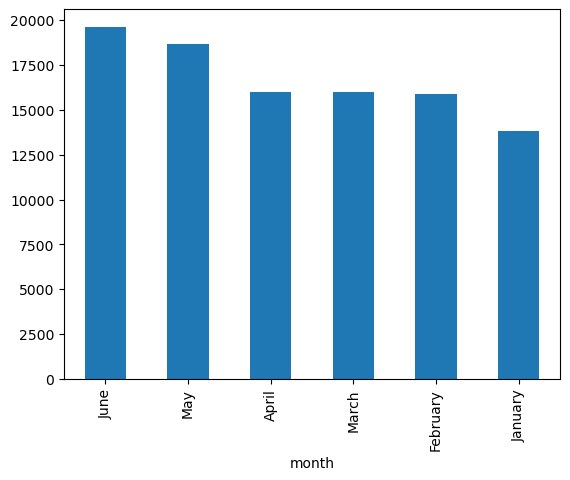

In [30]:
uber_15["month"].value_counts().plot(kind = "bar")

In [31]:
uber_15.head(4)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,day,hour
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,21
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,19
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,20
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,17


In [32]:
pivot = pd.crosstab(index = uber_15["month"], columns = uber_15["day"])

In [33]:
print(pivot)

day       Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
month                                                                   
April       2365    1833      2508    2052      2823     1880       2521
February    2655    1970      2550    2183      2396     2129       2013
January     2508    1353      2745    1651      2378     1444       1740
June        2793    2848      3037    2485      2767     3187       2503
March       2465    2115      2522    2379      2093     2388       2007
May         3262    1865      3519    2944      2627     2115       2328


In [34]:
month_order = ["January", "February", "March", "April", "May", "June" ]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

In [35]:
pivot_sorted = pivot.reindex(index = month_order).reindex(columns = day_order)

In [36]:
pivot_sorted

day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
month,,,,,,,
January,1353,1444,1740,2378,2508,2745,1651
February,1970,2129,2013,2396,2655,2550,2183
March,2115,2388,2007,2093,2465,2522,2379
April,1833,1880,2521,2823,2365,2508,2052
May,1865,2115,2328,2627,3262,3519,2944
June,2848,3187,2503,2767,2793,3037,2485


In [37]:
fig = px.bar(
    pivot_sorted,
    x=pivot_sorted.index,
    y=pivot_sorted.columns,
    barmode="group",
    title="Uber pickup by Month & days"
)

fig.show()


<Axes: xlabel='month'>

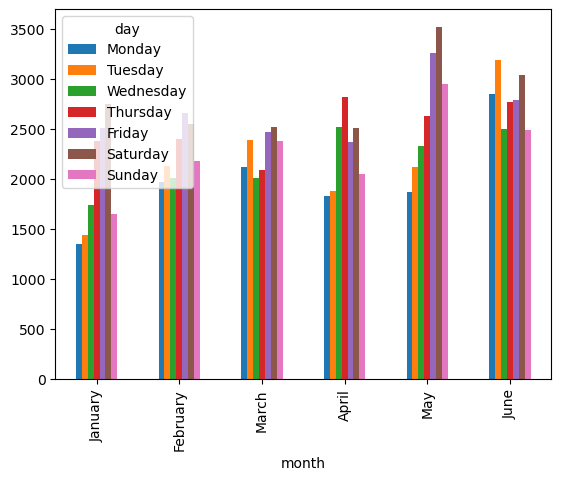

In [38]:
pivot_sorted.plot(kind="bar")

In [39]:
fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "Number of pickups",
    legend_title = "Days")

# Hourly Rush in new york city

In [40]:
uber_15.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month', 'day', 'hour'],
      dtype='object')

In [42]:
hourly_rush = uber_15.groupby(['day','hour'], as_index = False).size()

In [44]:
hourly_rush

,day,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,897
165,Wednesday,21,949
166,Wednesday,22,900


In [45]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

In [50]:
hourly_rush["day"] = pd.Categorical(hourly_rush["day"], categories = day_order, ordered = True)

In [51]:
hourly_rush.sort_values(["day", "hour"])

,day,hour,size
24,Monday,0,339
25,Monday,1,178
26,Monday,2,109
27,Monday,3,100
28,Monday,4,139
...,...,...,...
91,Sunday,19,711
92,Sunday,20,697
93,Sunday,21,615
94,Sunday,22,658


In [53]:
hourly_fig = px.line(
    hourly_rush,
    x='hour',
    y='size',
    color = 'day',
    markers = True,
    title="Hourly uber rush on days"
)

/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1958: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [55]:
hourly_fig.update_layout(
    xaxis_title = "Hour of day",
    yaxis_title = "Number of pickups",
    legend_title = "Day",
    template = "plotly_white"
)
    

# Pareto Analysis

In [58]:
base_counts = uber_15['Dispatching_base_num'].value_counts()

In [59]:
base_counts

Dispatching_base_num
B02764    40267
B02682    24460
B02617    14496
B02598    10644
B02765     8120
B02512     1757
B02835      193
B02836        9
Name: count, dtype: int64

In [60]:
base_counts.sum()

99946

In [61]:
base_counts/base_counts.sum()

Dispatching_base_num
B02764    0.402888
B02682    0.244732
B02617    0.145038
B02598    0.106498
B02765    0.081244
B02512    0.017579
B02835    0.001931
B02836    0.000090
Name: count, dtype: float64

In [62]:
base_df = base_counts.reset_index()

In [63]:
base_df

,Dispatching_base_num,count
0,B02764,40267
1,B02682,24460
2,B02617,14496
3,B02598,10644
4,B02765,8120
5,B02512,1757
6,B02835,193
7,B02836,9


In [64]:
base_df.columns = ["Base", "Trips"]
base_df

,Base,Trips
0,B02764,40267
1,B02682,24460
2,B02617,14496
3,B02598,10644
4,B02765,8120
5,B02512,1757
6,B02835,193
7,B02836,9


In [65]:
base_df["Trip_percentage"] = base_df['Trips']/base_df['Trips'].sum()
base_df

,Base,Trips,Trip_percentage
0,B02764,40267,0.402888
1,B02682,24460,0.244732
2,B02617,14496,0.145038
3,B02598,10644,0.106498
4,B02765,8120,0.081244
5,B02512,1757,0.017579
6,B02835,193,0.001931
7,B02836,9,0.000090


In [66]:
base_df["Cummulative_percentage"] = base_df["Trip_percentage"].cumsum()
base_df

,Base,Trips,Trip_percentage,Cummulative_percentage
0,B02764,40267,0.402888,0.402888
1,B02682,24460,0.244732,0.647620
2,B02617,14496,0.145038,0.792658
3,B02598,10644,0.106498,0.899156
4,B02765,8120,0.081244,0.980399
5,B02512,1757,0.017579,0.997979
6,B02835,193,0.001931,0.999910
7,B02836,9,0.000090,1.000000


In [68]:
px.bar(
    base_df,
    x = "Base",
    y = "Trip_percentage",
    title = "Pareto Analysis"
)

In [69]:
import plotly.graph_objs as go

In [72]:
pareto = go.Figure([
    go.Bar(x = base_df["Base"], y = base_df["Trips"], name = "Trips"),
    go.Scatter(x = base_df["Base"], y = base_df["Cummulative_percentage"], yaxis = 'y2', mode = "lines+markers", name = "Cummulative percentage")
])

In [73]:
pareto

In [88]:
pareto = pareto.update_layout(yaxis2 = dict(overlaying = 'y', side = "right", tickformat = ".0%", range = [0, 1]))

pareto.add_shape(
    type="line",
    x0=0,
    x1=1,
    xref="paper",
    y0=0.8,
    y1=0.8,
    yref="y2",
    line=dict(
        color="black",
        dash="dash"
    )
)

In [87]:
pareto

# Airport Demand analysis

In [92]:
uber_15.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month', 'day', 'hour'],
      dtype='object')

In [93]:
uber_15['locationID'].unique()

array([237, 231, 161, 107, 140,  87, 125,  68, 163, 235, 112, 233, 262,
       132, 141, 170, 226,  42,  48, 158, 148, 186, 246,  25, 164,  97,
       138,  76, 143, 200, 238, 239, 144, 232, 162, 236, 113, 229,  15,
         4,  40,  49, 106, 100,  79, 114, 155, 165, 149, 197,  74, 211,
       119,  88, 142, 249, 234, 263,  35,  22, 228, 181, 137, 255, 210,
        72,  41,  36, 230, 209, 123,  37,  13,  50, 225,  45,  28, 256,
        66,  65,  61, 224,  17,  82,  70, 151,  56, 157,   7, 223,  11,
        85,  43, 166,  90, 188, 227, 192,  33, 145, 261,  52, 258,  24,
        14, 135,  80, 134,  95, 102, 174, 216, 193, 241,  18, 185, 259,
       260, 130, 215,  75, 220, 179, 121, 212,  62, 160,  92, 116, 243,
       247, 146, 244, 248, 257, 178,  26, 133, 214, 124, 198,  73,  39,
        78, 129,  89, 128,  71, 171, 180,  10, 175, 126, 203,  83, 219,
        69, 196, 190, 189,  63, 150, 156, 213,   3, 183,  53,  91,  77,
       250, 168, 202, 205,  54, 177, 152, 195, 159,  86, 242,  2

In [94]:
airport_ids = [1, 132, 138]

In [97]:
airport_df = uber_15[uber_15['locationID'].isin(airport_ids)]

In [99]:
airport_map = {
    1: "EWR" ,
    132: "JFK" ,
    138: "LGA"
}

In [107]:
airport_df["airport_name"] = airport_df["locationID"].map(airport_map)

/var/folders/6g/knf3j5qj5gb58v052n2p7zcc0000gn/T/ipykernel_36351/1644202646.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [108]:
airport_df

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,day,hour,airpot_name,Pickup_hour,airport_name
15,B02617,2015-02-20 17:25:18,B02617,132,February,Friday,17,JFK,17,JFK
35,B02764,2015-04-12 17:28:00,B01998,138,April,Sunday,17,LGA,17,LGA
124,B02764,2015-03-19 16:06:00,B02764,138,March,Thursday,16,LGA,16,LGA
150,B02682,2015-03-28 22:53:00,B02598,138,March,Saturday,22,LGA,22,LGA
154,B02617,2015-01-09 02:10:51,B02617,138,January,Friday,2,LGA,2,LGA
...,...,...,...,...,...,...,...,...,...,...
99827,B02764,2015-06-10 22:30:00,B02764,138,June,Wednesday,22,LGA,22,LGA
99884,B02765,2015-04-28 00:45:00,B02769,132,April,Tuesday,0,JFK,0,JFK
99898,B02682,2015-05-29 00:11:00,B02682,132,May,Friday,0,JFK,0,JFK
99925,B02682,2015-05-18 11:32:00,B02682,138,May,Monday,11,LGA,11,LGA


In [109]:
airport_df["airport_name"].value_counts()

airport_name
JFK    1948
LGA    1923
Name: count, dtype: int64

In [113]:
airport_df["hour"] = airport_df["Pickup_date"].dt.hour

/var/folders/6g/knf3j5qj5gb58v052n2p7zcc0000gn/T/ipykernel_36351/817405670.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [116]:
airport_hourly = airport_df.groupby(["airport_name", "hour"]).size().reset_index(name = "trips")

In [118]:
area_fig = px.area(
    airport_hourly,
    x = "hour",
    y = "trips",
    color = "airport_name",
    title = "Airport demand"
)

In [119]:
area_fig.update_layout(
    xaxis_title = "Hours",
    yaxis_title = "Number of trips",
    legend_title = "Airport names"
)

# Collection of entire data for Data Analysis

In [121]:
os.listdir(r"/Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Datasets")

['other-Lyft_B02510.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Skyline_B00111.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-janjune-15.csv',
 'other-American_B01362.csv',
 'uber-raw-data-apr14.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'other-Highclass_B01717.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-sep14.csv',
 'uber-raw-data-jul14.csv',
 'other-Federal_02216.csv',
 'uber-raw-data-jun14.csv',
 'other-Carmel_B00256.csv',
 'other-Diplo_B01196.csv',
 'other-Dial7_B00887.csv',
 'uber-raw-data-may14.csv',
 'other-Prestige_B01338.csv']

In [122]:
files_csv = [
    'uber-raw-data-jul14.csv',
    'uber-raw-data-jun14.csv',
    'uber-raw-data-may14.csv',
    'uber-raw-data-sep14.csv',
    'uber-raw-data-aug14.csv',
    'uber-raw-data-apr14.csv'
]

In [123]:
final = pd.DataFrame()
path = r"/Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Datasets"

for file in files_csv:
    current_df = pd.read_csv(path + '/' + file)
    final = pd.concat([current_df, final])

In [124]:
final.shape

(4534327, 4)

In [126]:
final.drop_duplicates(inplace = True)

In [127]:
final.duplicated().sum()

0

# Data Loading 

In [128]:
final.to_csv(r'/Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Pre-processed_data/uber_full_data.csv', index = False)

In [129]:
final.reset_index().to_json(r'/Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Pre-processed_data/uber.json')

In [131]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [132]:
from sqlalchemy import create_engine

In [133]:
engine = create_engine(r'sqlite:////Users/alekhyaayinam/Desktop/Data analyst/Uber_Data_Analysis/Pre-processed_data/uber_db.sqlite')

In [134]:
final.to_sql("Trips", con = engine, if_exists = "append")

4451746

# Hourly rush via animated spatial analysis

In [135]:
final.dtypes

Date/Time     object
Lat          float64
Lon          float64
Base          object
dtype: object

In [137]:
final['Date/Time'] = pd.to_datetime(final['Date/Time'])

In [138]:
final.dtypes

Date/Time    datetime64[ns]
Lat                 float64
Lon                 float64
Base                 object
dtype: object

In [139]:
final['hour'] = final['Date/Time'].dt.hour

In [141]:
hourly_data = []

for h in range(24):
    temp = final[final["hour"] == h][["Lat" , "Lon"]]
    hourly_data. append(temp.values.tolist())

In [142]:
pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 2.5 MB/s eta 0:00:0031m2.6 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [143]:
import folium
from folium.plugins import HeatMapWithTime

In [144]:
m = folium.Map(
    location = [40.7128, -74.0060],
    zoom_start = 11,
    tiles = "cartodbpositron"
)

In [146]:
m

In [147]:
HeatMapWithTime(
    hourly_data,
    radius = 9,
    auto_play = False,
    max_opacity = 0.8).add_to(m)

In [ ]:
m